# C2_revision
## Controlled Entanglement Ablation with Matched Baselines and Hardware-Noise Validation

**Primary question:**  
Does ZZ entanglement provide incremental value over a matched non-entangling ZFeatureMap at the frozen C1 operating point?

**Secondary question:**  
Does the observed kernel behavior remain identifiable under finite-shot and realistic hardware-noise simulation?

Notebook này **không reselect PCA dimension**, không fit lại C1 transformer, và không tạo lại dataset. C2 chỉ consume C1 frozen representation, dedicated tuning set, 10 training runs, và fixed test set.

## 1. Configuration contract

In [1]:
import hashlib
import json
import os
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import t, wilcoxon
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = repr(exc)

from qiskit.circuit.library import z_feature_map, zz_feature_map
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityStatevectorKernel


def find_project_root(start=None):
    """Tìm root repo bằng config.py để notebook chạy được từ nhiều cwd."""
    here = Path(start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "config.py").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy config.py trong cwd hoặc parent directories.")


ROOT_DIR = find_project_root()
os.chdir(ROOT_DIR)

from config import (  # noqa: E402
    LABEL_COLS,
    NSLKDD_MODELS_DIR,
    NSLKDD_PROCESSED_DIR,
    NSLKDD_RESULTS_DIR,
)

OUTPUT_DIR = NSLKDD_RESULTS_DIR / "c2_revision"
FIGURE_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = OUTPUT_DIR / "cache"
for path in [OUTPUT_DIR, FIGURE_DIR, CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# --- Cache control -------------------------------------------------------
# FORCE_RERUN=True bỏ qua toàn bộ cache (tuning + per-run) và tính lại từ đầu.
# RUN_IDS_TO_EXECUTE: chạy pilot Run 1 trước. Chỉ sau khi pilot pass mới đổi
# thành list(range(1, 11)) để chạy full 10 runs.
FORCE_RERUN = False
RUN_IDS_TO_EXECUTE = list(range(1, 11))  # [1] để chạy pilot run 1 trước, sau đó đổi thành list(range(1, 11)) để chạy full 10 runs.

C2_CONFIG = {
    "selected_n": 4,
    "reps": 2,
    "entanglement": "full",
    "n_runs": 10,
    "run_size": 1000,
    "tuning_size": 2000,
    "tuning_seed": 200,
    "run_seeds": list(range(100, 110)),
    "cv_folds": 5,
    "cv_scoring": "f1_macro",
    "c_selection": "1SE",
    "kta_sample_size": 200,
    "kta_seed_base": 1000,
    "c_candidates": [0.1, 0.3, 0.5, 1.0, 3.0, 5.0, 10.0],
    # RF/XGB grids định nghĩa ở đây (thay vì rải trong cell tuning) để nằm trong
    # CONFIG_SIGNATURE ngay từ đầu — đổi grid sẽ tự làm cache tuning cũ invalid.
    "rf_grid": {
        "n_estimators": [200, 500],
        "max_depth": [None, 10, 20],
        "min_samples_leaf": [1, 2],
    },
    "xgb_grid": {
        "n_estimators": [200, 500],
        "max_depth": [3, 5],
        "learning_rate": [0.03, 0.1],
        "subsample": [0.8, 1.0],
    },
    "fixed_test_path": str(NSLKDD_PROCESSED_DIR / "NSL_KDD_Test_Sample300.csv"),
    "test_size": 300,
    "random_state": 42,
    "force_rerun": FORCE_RERUN,
    "run_ids_to_execute": RUN_IDS_TO_EXECUTE,
    "quantum_backend": "FidelityStatevectorKernel",
    "noise_validation_enabled": True,
    "noise_shots": 512,
    "noise_run_id": 1,
    # Cỡ subsample (stratified) từ fixed test set, dùng riêng cho so sánh
    # F1_ideal_statevector / F1_ideal_finite_shot / F1_noisy trong noise validation.
    # Nhỏ hơn test_size đầy đủ (300) để việc train+predict QSVC bằng noisy kernel
    # (mỗi entry train-test là một circuit sim có shots) vẫn tractable.
    "noise_f1_test_size": 300,
    # Fixed IBM FakeBackend candidates cho noise validation, theo thứ tự ưu tiên.
    # Đưa vào config (thay vì hardcode trong hàm) để nằm trong CONFIG_SIGNATURE.
    "noise_backend_candidates": [
        ["qiskit_ibm_runtime.fake_provider", "FakeManilaV2"],
        ["qiskit.providers.fake_provider", "FakeManilaV2"],
    ],
}

assert C2_CONFIG["selected_n"] == 4
assert len(C2_CONFIG["run_seeds"]) == 10
assert C2_CONFIG["tuning_size"] == 2000


def compute_config_signature(config):
    """Hash mọi field ảnh hưởng tới kết quả thí nghiệm (không gồm force_rerun/
    run_ids_to_execute, vốn chỉ là execution control chứ không đổi experiment definition),
    dùng để tự phát hiện cache thuộc về một config cũ và tránh dùng nhầm kết quả.

    BLOCKER #1 fix: bổ sung rf_grid, xgb_grid, fixed_test_path, và toàn bộ noise config
    (trước đây thiếu, khiến đổi các field này không invalid cache cũ)."""
    signature_fields = {
        "selected_n": config["selected_n"],
        "reps": config["reps"],
        "entanglement": config["entanglement"],
        "run_size": config["run_size"],
        "tuning_size": config["tuning_size"],
        "tuning_seed": config["tuning_seed"],
        "run_seeds": config["run_seeds"],
        "cv_folds": config["cv_folds"],
        "cv_scoring": config["cv_scoring"],
        "c_selection": config["c_selection"],
        "kta_sample_size": config["kta_sample_size"],
        "kta_seed_base": config["kta_seed_base"],
        "c_candidates": config["c_candidates"],
        "rf_grid": config["rf_grid"],
        "xgb_grid": config["xgb_grid"],
        "fixed_test_path": config["fixed_test_path"],
        "test_size": config["test_size"],
        "random_state": config["random_state"],
        "noise_validation_enabled": config["noise_validation_enabled"],
        "noise_shots": config["noise_shots"],
        "noise_run_id": config["noise_run_id"],
        "noise_backend_candidates": config["noise_backend_candidates"],
        "noise_f1_test_size": config["noise_f1_test_size"],
    }
    payload = json.dumps(signature_fields, sort_keys=True).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()[:16]


CONFIG_SIGNATURE = compute_config_signature(C2_CONFIG)
C2_CONFIG["config_signature"] = CONFIG_SIGNATURE


def load_cache_if_valid(cache_path):
    """Trả cache nếu tồn tại, KHÔNG FORCE_RERUN, và config_signature khớp config hiện tại.
    Nếu không, trả None để cell gọi tự tính lại (run_experiment)."""
    if FORCE_RERUN or not cache_path.exists():
        return None
    try:
        with open(cache_path, "r", encoding="utf-8") as fp:
            cached = json.load(fp)
    except (json.JSONDecodeError, OSError):
        return None
    if cached.get("config_signature") != CONFIG_SIGNATURE:
        return None
    return cached


def save_cache(cache_path, payload):
    """Lưu cache kèm config_signature để lần chạy sau tự phát hiện config đã đổi."""
    payload = dict(payload)
    payload["config_signature"] = CONFIG_SIGNATURE
    with open(cache_path, "w", encoding="utf-8") as fp:
        json.dump(payload, fp, indent=2, ensure_ascii=False)


with open(OUTPUT_DIR / "c2_config.json", "w", encoding="utf-8") as fp:
    json.dump(C2_CONFIG, fp, indent=2, ensure_ascii=False)

np.random.seed(C2_CONFIG["random_state"])
print(f"ROOT_DIR          : {ROOT_DIR}")
print(f"OUTPUT_DIR        : {OUTPUT_DIR}")
print(f"Fixed test        : {C2_CONFIG['fixed_test_path']}")
print(f"FORCE_RERUN       : {FORCE_RERUN}")
print(f"RUN_IDS_TO_EXECUTE: {RUN_IDS_TO_EXECUTE}")
print(f"Config signature  : {CONFIG_SIGNATURE}")


ROOT_DIR          : D:\QSVM_NSLKDD
OUTPUT_DIR        : D:\QSVM_NSLKDD\results\nslkdd\c2_revision
Fixed test        : D:\QSVM_NSLKDD\data\nslkdd\processed_data\NSL_KDD_Test_Sample300.csv
FORCE_RERUN       : False
RUN_IDS_TO_EXECUTE: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Config signature  : a89a6eb55d27b0a6


## 2. Load and verify C1 frozen artifact

In [2]:
c1_selection_path = NSLKDD_PROCESSED_DIR / "c1_selection.json"
selector_path = NSLKDD_MODELS_DIR / "feature_selector_k20.joblib"
pca_path = NSLKDD_MODELS_DIR / "pca_4components.joblib"
scaler_path = NSLKDD_MODELS_DIR / "scaler_minmax_pi.joblib"

with open(c1_selection_path, "r", encoding="utf-8") as fp:
    c1_selection = json.load(fp)

selector = joblib.load(selector_path)
pca = joblib.load(pca_path)
angle_scaler = joblib.load(scaler_path)

assert int(c1_selection["selected_n"]) == C2_CONFIG["selected_n"]
assert int(pca.n_components_) == C2_CONFIG["selected_n"]
assert int(selector.k) == 20

print(f"C1 selected_n : {c1_selection['selected_n']}")
print(f"SelectKBest   : k={selector.k}")
print(f"PCA           : n_components={pca.n_components_}, variance={pca.explained_variance_ratio_.sum():.4f}")
print(f"Angle scaler  : range={angle_scaler.feature_range}")

C1 selected_n : 4
SelectKBest   : k=20
PCA           : n_components=4, variance=0.8662
Angle scaler  : range=(0.0, 3.141592653589793)


## 3. Load datasets and verify protocol

In [3]:
tuning_path = NSLKDD_PROCESSED_DIR / "c2_tuning" / "train_tuning_2000.csv"
multi_run_dir = NSLKDD_PROCESSED_DIR / "multi_run"
protocol_path = multi_run_dir / "dataset_protocol.json"
test_path = Path(C2_CONFIG["fixed_test_path"])

with open(protocol_path, "r", encoding="utf-8") as fp:
    dataset_protocol = json.load(fp)

df_tune = pd.read_csv(tuning_path)
df_test = pd.read_csv(test_path)
run_frames = {
    run_id: pd.read_csv(multi_run_dir / f"train_run{run_id}.csv")
    for run_id in range(1, C2_CONFIG["n_runs"] + 1)
}

assert len(df_tune) == C2_CONFIG["tuning_size"]
assert len(run_frames) == C2_CONFIG["n_runs"]
assert all(len(df) == C2_CONFIG["run_size"] for df in run_frames.values())
assert dataset_protocol.get("tuning_disjoint_from_runs") is True

feature_cols = [c for c in df_tune.columns if c not in LABEL_COLS]
assert feature_cols == [c for c in df_test.columns if c not in LABEL_COLS]
assert all(feature_cols == [c for c in df.columns if c not in LABEL_COLS] for df in run_frames.values())

def dataframe_signature_set(df):
    """Tạo row signatures để double-check overlap khi CSV không còn source id."""
    return set(pd.util.hash_pandas_object(df[feature_cols + ["label_binary"]], index=False).astype("uint64"))

tune_signatures = dataframe_signature_set(df_tune)
run_overlap_counts = {
    run_id: len(tune_signatures & dataframe_signature_set(df))
    for run_id, df in run_frames.items()
}
assert max(run_overlap_counts.values()) == 0

print(f"Tuning set : {df_tune.shape} | path={tuning_path}")
print(f"Test set   : {df_test.shape} | path={test_path}")
print(f"Runs       : {len(run_frames)} x {C2_CONFIG['run_size']}")
print(f"Overlap D_tune ∩ D_run_i: {run_overlap_counts}")

Tuning set : (2000, 126) | path=D:\QSVM_NSLKDD\data\nslkdd\processed_data\c2_tuning\train_tuning_2000.csv
Test set   : (300, 126) | path=D:\QSVM_NSLKDD\data\nslkdd\processed_data\NSL_KDD_Test_Sample300.csv
Runs       : 10 x 1000
Overlap D_tune ∩ D_run_i: {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0}


## 4. Frozen preprocessing transformation

In [4]:
ANGLE_MAX = np.pi

def frozen_transform_angles(df):
    """Chỉ transform bằng C1 artifact đã fit; tuyệt đối không fit lại."""
    X_raw = df[feature_cols].to_numpy(dtype=np.float32)
    X_sel = selector.transform(X_raw)
    X_pca = pca.transform(X_sel)
    X_ang = angle_scaler.transform(X_pca)
    return np.clip(X_ang, 0.0, ANGLE_MAX)


def frozen_transform_pca(df):
    """Trả PCA frozen trước MinMax để classical branch tự fit scaler đúng protocol."""
    X_raw = df[feature_cols].to_numpy(dtype=np.float32)
    X_sel = selector.transform(X_raw)
    return pca.transform(X_sel)


X_tune_ang = frozen_transform_angles(df_tune)
X_tune_pca = frozen_transform_pca(df_tune)
y_tune = df_tune["label_binary"].to_numpy(dtype=np.int64)

X_test_ang = frozen_transform_angles(df_test)
X_test_pca = frozen_transform_pca(df_test)
y_test = df_test["label_binary"].to_numpy(dtype=np.int64)

assert X_tune_ang.shape == (C2_CONFIG["tuning_size"], C2_CONFIG["selected_n"])
assert X_test_ang.shape[1] == C2_CONFIG["selected_n"]
assert np.isfinite(X_tune_ang).all()
assert np.isfinite(X_test_ang).all()

print(f"X_tune_ang : {X_tune_ang.shape} | range=[{X_tune_ang.min():.4f}, {X_tune_ang.max():.4f}]")
print(f"X_test_ang : {X_test_ang.shape} | range=[{X_test_ang.min():.4f}, {X_test_ang.max():.4f}]")

X_tune_ang : (2000, 4) | range=[0.0082, 3.1416]
X_test_ang : (300, 4) | range=[0.0325, 3.1416]


## 5. Dedicated hyperparameter tuning

In [5]:
cv = StratifiedKFold(
    n_splits=C2_CONFIG["cv_folds"],
    shuffle=True,
    random_state=C2_CONFIG["random_state"],
)

def select_one_se(rows, score_col="mean_score", se_col="se_score", complexity_col="complexity"):
    """True 1-SE: chọn cấu hình đơn giản nhất nằm trong best_mean - SE(best).
    Dùng cho SVM/QSVM, nơi complexity (vd. C) có ý nghĩa thật, không phải scalar tự chế."""
    best = max(rows, key=lambda r: r[score_col])
    threshold = best[score_col] - best[se_col]
    eligible = [r for r in rows if r[score_col] >= threshold]
    return min(eligible, key=lambda r: r[complexity_col]), best, threshold


def select_best_mean(rows, score_col="mean_score"):
    """RF/XGB: chọn cấu hình best mean CV macro-F1, tie-break deterministic theo thứ tự
    xuất hiện trong grid (không dùng complexity scalar tự định nghĩa)."""
    best_score = max(r[score_col] for r in rows)
    candidates = [r for r in rows if r[score_col] == best_score]
    chosen = candidates[0]
    return chosen, chosen, None


def build_zz_kernel(shots=None):
    """Kernel statevector ZZFeatureMap cho main C2."""
    feature_map = zz_feature_map(
        feature_dimension=C2_CONFIG["selected_n"],
        reps=C2_CONFIG["reps"],
        entanglement=C2_CONFIG["entanglement"],
    )
    return FidelityStatevectorKernel(feature_map=feature_map, shots=shots, enforce_psd=True)


def build_z_kernel(shots=None):
    """Kernel statevector ZFeatureMap không entangle cho ablation."""
    feature_map = z_feature_map(
        feature_dimension=C2_CONFIG["selected_n"],
        reps=C2_CONFIG["reps"],
    )
    return FidelityStatevectorKernel(feature_map=feature_map, shots=shots, enforce_psd=True)


def tune_quantum_c_with_cache():
    """Tune C_Q trên tuning set bằng ZZ kernel (true 1-SE); Z dùng cùng C sau khi freeze."""
    cache_path = CACHE_DIR / "quantum_c_tuning.json"
    cached = load_cache_if_valid(cache_path)
    if cached is not None:
        return cached

    rows = []
    for c_value in C2_CONFIG["c_candidates"]:
        fold_scores = []
        t0 = time.time()
        for train_idx, val_idx in cv.split(X_tune_ang, y_tune):
            model = QSVC(
                quantum_kernel=build_zz_kernel(shots=None),
                C=float(c_value),
                random_state=C2_CONFIG["random_state"],
            )
            model.fit(X_tune_ang[train_idx], y_tune[train_idx])
            pred = model.predict(X_tune_ang[val_idx])
            fold_scores.append(f1_score(y_tune[val_idx], pred, average="macro"))
        scores = np.asarray(fold_scores, dtype=float)
        row = {
            "model": "QSVM_ZZ_tuning_for_shared_C",
            "C": float(c_value),
            "mean_score": float(scores.mean()),
            "std_score": float(scores.std(ddof=1)),
            "se_score": float(scores.std(ddof=1) / np.sqrt(len(scores))),
            "n_folds": int(len(scores)),
            "elapsed_sec": float(time.time() - t0),
            "complexity": float(c_value),
        }
        rows.append(row)
        print(f"[QSVM C] C={c_value:<4} F1={row['mean_score']:.4f} SE={row['se_score']:.4f}")

    chosen, best, threshold = select_one_se(rows)
    result = {"chosen": chosen, "best": best, "threshold": threshold, "rows": rows, "selection": "1SE"}
    save_cache(cache_path, result)
    return result


def tune_grid_with_cache(model_name, estimator, param_grid, X, y, complexity_fn=None, selection="1SE"):
    """Tune baseline bằng GridSearchCV trên tuning set.

    selection="1SE"       -> true 1-SE (SVM/QSVM); yêu cầu complexity_fn thật (vd. C).
    selection="best_mean" -> best mean CV macro-F1, tie-break deterministic (RF/XGB);
                              không dùng complexity scalar tự định nghĩa.
    """
    if selection == "1SE" and complexity_fn is None:
        raise ValueError("selection='1SE' cần complexity_fn.")

    cache_path = CACHE_DIR / f"{model_name}_tuning.json"
    cached = load_cache_if_valid(cache_path)
    if cached is not None:
        return cached

    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=C2_CONFIG["cv_scoring"],
        cv=cv,
        n_jobs=-1,
        refit=False,
        return_train_score=False,
    )
    search.fit(X, y)
    rows = []
    for i, params in enumerate(search.cv_results_["params"]):
        split_scores = np.array(
            [search.cv_results_[f"split{fold}_test_score"][i] for fold in range(C2_CONFIG["cv_folds"])],
            dtype=float,
        )
        row = {
            "model": model_name,
            "params": params,
            "mean_score": float(split_scores.mean()),
            "std_score": float(split_scores.std(ddof=1)),
            "se_score": float(split_scores.std(ddof=1) / np.sqrt(len(split_scores))),
            "n_folds": int(len(split_scores)),
        }
        if selection == "1SE":
            row["complexity"] = float(complexity_fn(params))
        rows.append(row)

    if selection == "1SE":
        chosen, best, threshold = select_one_se(rows)
    elif selection == "best_mean":
        chosen, best, threshold = select_best_mean(rows)
    else:
        raise ValueError(f"Unknown selection rule: {selection}")

    result = {"chosen": chosen, "best": best, "threshold": threshold, "rows": rows, "selection": selection}
    save_cache(cache_path, result)
    print(f"[{model_name}] selection={selection} | chosen={chosen['params']} | best={best['params']}")
    return result


quantum_tuning = tune_quantum_c_with_cache()
C_Q = float(quantum_tuning["chosen"]["C"])
C_ZZ = C_Q
C_Z = C_Q
assert C_ZZ == C_Z
print(f"Frozen quantum C: C_ZZ = C_Z = {C_Q}")


[QSVM C] C=0.1  F1=0.8938 SE=0.0063


[QSVM C] C=0.3  F1=0.9129 SE=0.0078


[QSVM C] C=0.5  F1=0.9190 SE=0.0066


[QSVM C] C=1.0  F1=0.9250 SE=0.0076


[QSVM C] C=3.0  F1=0.9409 SE=0.0060


[QSVM C] C=5.0  F1=0.9339 SE=0.0049


[QSVM C] C=10.0 F1=0.9329 SE=0.0043
Frozen quantum C: C_ZZ = C_Z = 3.0


In [6]:
svm_c_grid = {"svc__C": C2_CONFIG["c_candidates"]}

# probability=False: C2 chỉ dùng predict() để lấy F1, không cần Platt-scaling
# calibration (vốn chậm hơn và thêm một stochastic step không cần thiết).
# Không còn probability=True nên random_state của SVC cũng không cần thiết nữa.
svm_estimators = {
    "SVM_Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", probability=False)),
    ]),
    "SVM_Poly2": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="poly", degree=2, gamma="scale", probability=False)),
    ]),
    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", gamma="scale", probability=False)),
    ]),
}

baseline_tuning = {}
for name, estimator in svm_estimators.items():
    baseline_tuning[name] = tune_grid_with_cache(
        name,
        estimator,
        svm_c_grid,
        X_tune_pca,
        y_tune,
        complexity_fn=lambda params: params["svc__C"],
        selection="1SE",
    )

# RF/XGB: best mean CV macro-F1, không dùng complexity scalar tự định nghĩa (mục D).
# Grid lấy từ C2_CONFIG (đã nằm trong CONFIG_SIGNATURE) thay vì định nghĩa lại ở đây,
# để đổi grid sẽ tự làm cache tuning cũ invalid (BLOCKER #1 fix).
baseline_tuning["RandomForest"] = tune_grid_with_cache(
    "RandomForest",
    RandomForestClassifier(random_state=C2_CONFIG["random_state"], n_jobs=-1, class_weight="balanced_subsample"),
    C2_CONFIG["rf_grid"],
    X_tune_pca,
    y_tune,
    selection="best_mean",
)

if XGBOOST_AVAILABLE:
    baseline_tuning["XGBoost"] = tune_grid_with_cache(
        "XGBoost",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=C2_CONFIG["random_state"],
            n_jobs=1,
            tree_method="hist",
        ),
        C2_CONFIG["xgb_grid"],
        X_tune_pca,
        y_tune,
        selection="best_mean",
    )
else:
    baseline_tuning["XGBoost"] = {
        "skipped": True,
        "reason": XGBOOST_IMPORT_ERROR,
        "rows": [],
    }
    print(f"[XGBoost] skipped: {XGBOOST_IMPORT_ERROR}")


[SVM_Linear] selection=1SE | chosen={'svc__C': 0.1} | best={'svc__C': 0.1}
[SVM_Poly2] selection=1SE | chosen={'svc__C': 0.1} | best={'svc__C': 3.0}


[SVM_RBF] selection=1SE | chosen={'svc__C': 5.0} | best={'svc__C': 5.0}


[RandomForest] selection=best_mean | chosen={'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200} | best={'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}


[XGBoost] selection=best_mean | chosen={'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8} | best={'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}


## 5.3 Freeze hyperparameters

In [7]:
def chosen_params(tuning_result):
    """Lấy params đã chọn từ kết quả tuning."""
    if tuning_result.get("skipped"):
        return {"skipped": True, "reason": tuning_result["reason"]}
    return tuning_result["chosen"]["params"]


FROZEN_HYPERPARAMETERS = {
    "QSVM_ZZ": {"C": C_ZZ, "feature_map": "ZZFeatureMap", "reps": C2_CONFIG["reps"], "entanglement": C2_CONFIG["entanglement"]},
    "QSVM_Z": {"C": C_Z, "feature_map": "ZFeatureMap", "reps": C2_CONFIG["reps"]},
    "SVM_Linear": chosen_params(baseline_tuning["SVM_Linear"]),
    "SVM_Poly2": chosen_params(baseline_tuning["SVM_Poly2"]),
    "SVM_RBF": chosen_params(baseline_tuning["SVM_RBF"]),
    "RandomForest": chosen_params(baseline_tuning["RandomForest"]),
    "XGBoost": chosen_params(baseline_tuning["XGBoost"]),
}

assert FROZEN_HYPERPARAMETERS["QSVM_ZZ"]["C"] == FROZEN_HYPERPARAMETERS["QSVM_Z"]["C"]

with open(OUTPUT_DIR / "c2_hyperparameters.json", "w", encoding="utf-8") as fp:
    json.dump(FROZEN_HYPERPARAMETERS, fp, indent=2, ensure_ascii=False)

cv_rows = []
cv_rows.extend(quantum_tuning["rows"])
for tuning_result in baseline_tuning.values():
    cv_rows.extend(tuning_result.get("rows", []))
cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(OUTPUT_DIR / "c2_cv_results.csv", index=False)

print(json.dumps(FROZEN_HYPERPARAMETERS, indent=2, ensure_ascii=False))
print(f"Saved: {OUTPUT_DIR / 'c2_hyperparameters.json'}")
print(f"Saved: {OUTPUT_DIR / 'c2_cv_results.csv'}")

{
  "QSVM_ZZ": {
    "C": 3.0,
    "feature_map": "ZZFeatureMap",
    "reps": 2,
    "entanglement": "full"
  },
  "QSVM_Z": {
    "C": 3.0,
    "feature_map": "ZFeatureMap",
    "reps": 2
  },
  "SVM_Linear": {
    "svc__C": 0.1
  },
  "SVM_Poly2": {
    "svc__C": 0.1
  },
  "SVM_RBF": {
    "svc__C": 5.0
  },
  "RandomForest": {
    "max_depth": null,
    "min_samples_leaf": 1,
    "n_estimators": 200
  },
  "XGBoost": {
    "learning_rate": 0.1,
    "max_depth": 5,
    "n_estimators": 500,
    "subsample": 0.8
  }
}
Saved: D:\QSVM_NSLKDD\results\nslkdd\c2_revision\c2_hyperparameters.json
Saved: D:\QSVM_NSLKDD\results\nslkdd\c2_revision\c2_cv_results.csv


## 6. KTA subset protocol

In [8]:
def stratified_binary_indices(y, n_samples, random_state):
    """Lấy subset binary stratified, dùng cùng indices cho ZZ và Z trong run."""
    rng = np.random.RandomState(random_state)
    y = np.asarray(y)
    classes, counts = np.unique(y, return_counts=True)
    allocations = np.floor(counts / counts.sum() * n_samples).astype(int)
    while allocations.sum() < n_samples:
        allocations[np.argmax(counts / counts.sum() * n_samples - allocations)] += 1
    selected = []
    for cls, n_take in zip(classes, allocations):
        pool = np.where(y == cls)[0]
        selected.extend(rng.choice(pool, size=min(n_take, len(pool)), replace=False).tolist())
    selected = np.asarray(selected, dtype=int)
    rng.shuffle(selected)
    return selected


def kernel_target_alignment(K, y):
    """Tính KTA giữa Gram matrix và nhãn nhị phân {-1, +1}."""
    yy = y.astype(float).copy()
    yy[yy == 0] = -1.0
    Y = np.outer(yy, yy)
    denominator = np.linalg.norm(K, "fro") * np.linalg.norm(Y, "fro")
    return float(np.sum(K * Y) / denominator) if denominator > 1e-12 else 0.0


def kta_for_run(X_train_ang, y_train, run_id):
    """Tính KTA ZZ/Z trên subset riêng của từng run."""
    idx = stratified_binary_indices(
        y_train,
        C2_CONFIG["kta_sample_size"],
        random_state=1000 + int(run_id),
    )
    X_kta = X_train_ang[idx]
    y_kta = y_train[idx]
    K_zz = build_zz_kernel(shots=None).evaluate(X_kta)
    K_z = build_z_kernel(shots=None).evaluate(X_kta)
    return {
        "run_id": int(run_id),
        "kta_seed": int(1000 + int(run_id)),
        "kta_sample_size": int(len(idx)),
        "QSVM_ZZ": kernel_target_alignment(K_zz, y_kta),
        "QSVM_Z": kernel_target_alignment(K_z, y_kta),
        "kta_indices": idx.tolist(),
    }

## 7. Main 10-run experiment

In [9]:
def make_baseline_models(run_seed):
    """Khởi tạo model từ frozen hyperparameters cho một run.

    Hyperparameters (từ tuning trên dedicated tuning set) giữ nguyên/đóng băng cho mọi run.
    random_state của các stochastic component (RF, XGBoost) dùng
    run_seed = 100 + run_id - 1, tức tái sử dụng đúng seed của bộ 10 dataset,
    không tạo bộ seed riêng cho từng model. SVM dùng probability=False nên không còn
    stochastic component / random_state nào cần propagate.
    """
    models = {}
    for name in ["SVM_Linear", "SVM_Poly2", "SVM_RBF"]:
        estimator = clone(svm_estimators[name])
        estimator.set_params(**FROZEN_HYPERPARAMETERS[name])
        models[name] = estimator

    rf = RandomForestClassifier(
        random_state=run_seed,
        n_jobs=-1,
        class_weight="balanced_subsample",
        **FROZEN_HYPERPARAMETERS["RandomForest"],
    )
    models["RandomForest"] = rf

    if XGBOOST_AVAILABLE and not FROZEN_HYPERPARAMETERS["XGBoost"].get("skipped", False):
        models["XGBoost"] = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=run_seed,
            n_jobs=1,
            tree_method="hist",
            **FROZEN_HYPERPARAMETERS["XGBoost"],
        )
    return models


def evaluate_classifier(model, X_test_data, y_test_data, y_train_data=None):
    """Đánh giá classifier trên fixed test set."""
    pred = model.predict(X_test_data)
    result = {
        "f1_macro": float(f1_score(y_test_data, pred, average="macro")),
        "accuracy": float(accuracy_score(y_test_data, pred)),
    }
    if hasattr(model, "n_support_"):
        result["n_support_vectors"] = int(np.sum(model.n_support_))
        result["support_vectors_per_class"] = [int(v) for v in model.n_support_]
    elif hasattr(model, "support_") and y_train_data is not None:
        result["n_support_vectors"] = int(len(model.support_))
    else:
        result["n_support_vectors"] = None
    return result


def run_single_c2(run_id):
    """Chạy một paired run: cùng train/test/split cho ZZ, Z và baselines.

    Cache: if cache_exists and not FORCE_RERUN -> load_cache(); else -> run_experiment().
    Cache lưu kèm config_signature nên tự invalid nếu config đổi.
    """
    cache_path = CACHE_DIR / f"run_{run_id}_results.json"
    cached = load_cache_if_valid(cache_path)
    if cached is not None:
        return cached

    run_seed = int(C2_CONFIG["run_seeds"][int(run_id) - 1])  # 100 + run_id - 1

    df_train = run_frames[int(run_id)]
    X_train_ang = frozen_transform_angles(df_train)
    X_train_pca = frozen_transform_pca(df_train)
    y_train = df_train["label_binary"].to_numpy(dtype=np.int64)

    print(f"[C2 run {run_id}] train={X_train_ang.shape}, test={X_test_ang.shape}, run_seed={run_seed}")

    run_result = {
        "run_id": int(run_id),
        "seed": run_seed,
        "train_size": int(len(df_train)),
        "test_size": int(len(df_test)),
        "models": {},
    }

    t0 = time.time()
    qsvm_zz = QSVC(quantum_kernel=build_zz_kernel(shots=None), C=C_ZZ, random_state=C2_CONFIG["random_state"])
    qsvm_zz.fit(X_train_ang, y_train)
    run_result["models"]["QSVM_ZZ"] = evaluate_classifier(qsvm_zz, X_test_ang, y_test, y_train)
    run_result["models"]["QSVM_ZZ"]["elapsed_sec"] = float(time.time() - t0)

    t0 = time.time()
    qsvm_z = QSVC(quantum_kernel=build_z_kernel(shots=None), C=C_Z, random_state=C2_CONFIG["random_state"])
    qsvm_z.fit(X_train_ang, y_train)
    run_result["models"]["QSVM_Z"] = evaluate_classifier(qsvm_z, X_test_ang, y_test, y_train)
    run_result["models"]["QSVM_Z"]["elapsed_sec"] = float(time.time() - t0)

    kta_result = kta_for_run(X_train_ang, y_train, run_id)
    run_result["models"]["QSVM_ZZ"]["kta"] = float(kta_result["QSVM_ZZ"])
    run_result["models"]["QSVM_Z"]["kta"] = float(kta_result["QSVM_Z"])
    run_result["kta_protocol"] = {
        "kta_seed": kta_result["kta_seed"],
        "kta_sample_size": kta_result["kta_sample_size"],
        "kta_indices": kta_result["kta_indices"],
    }

    for name, model in make_baseline_models(run_seed).items():
        t0 = time.time()
        model.fit(X_train_pca, y_train)
        run_result["models"][name] = evaluate_classifier(model, X_test_pca, y_test, y_train)
        run_result["models"][name]["elapsed_sec"] = float(time.time() - t0)

    save_cache(cache_path, run_result)
    return run_result


all_run_results = [run_single_c2(run_id) for run_id in C2_CONFIG["run_ids_to_execute"]]

per_run_rows = []
kta_rows = []
for result in all_run_results:
    for model_name, metrics in result["models"].items():
        row = {
            "run_id": result["run_id"],
            "seed": result["seed"],
            "model": model_name,
            "f1_macro": metrics.get("f1_macro"),
            "accuracy": metrics.get("accuracy"),
            "kta": metrics.get("kta"),
            "n_support_vectors": metrics.get("n_support_vectors"),
            "elapsed_sec": metrics.get("elapsed_sec"),
        }
        per_run_rows.append(row)
    kta_rows.append({
        "run_id": result["run_id"],
        "seed": result["seed"],
        "kta_seed": result["kta_protocol"]["kta_seed"],
        "kta_sample_size": result["kta_protocol"]["kta_sample_size"],
        "kta_zz": result["models"]["QSVM_ZZ"].get("kta"),
        "kta_z": result["models"]["QSVM_Z"].get("kta"),
        "delta_kta": result["models"]["QSVM_ZZ"].get("kta") - result["models"]["QSVM_Z"].get("kta"),
    })

per_run_df = pd.DataFrame(per_run_rows)
kta_df = pd.DataFrame(kta_rows)
per_run_df.to_csv(OUTPUT_DIR / "c2_per_run.csv", index=False)
kta_df.to_csv(OUTPUT_DIR / "c2_kta_per_run.csv", index=False)

display(per_run_df)


[C2 run 1] train=(1000, 4), test=(300, 4), run_seed=100


[C2 run 2] train=(1000, 4), test=(300, 4), run_seed=101


[C2 run 3] train=(1000, 4), test=(300, 4), run_seed=102


[C2 run 4] train=(1000, 4), test=(300, 4), run_seed=103


[C2 run 5] train=(1000, 4), test=(300, 4), run_seed=104


...

[C2 run 7] train=(1000, 4), test=(300, 4), run_seed=106


[C2 run 8] train=(1000, 4), test=(300, 4), run_seed=107


[C2 run 9] train=(1000, 4), test=(300, 4), run_seed=108


[C2 run 10] train=(1000, 4), test=(300, 4), run_seed=109


,run_id,seed,model,f1_macro,accuracy,kta,n_support_vectors,elapsed_sec
0,1,100,QSVM_ZZ,0.873192,0.873333,0.202949,223.0,6.570057
1,1,100,QSVM_Z,0.819800,0.820000,0.066837,273.0,5.314058
2,1,100,SVM_Linear,0.822764,0.823333,NaN,NaN,0.000000
3,1,100,SVM_Poly2,0.846229,0.846667,NaN,NaN,0.010861
4,1,100,SVM_RBF,0.849798,0.850000,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...
65,10,109,SVM_Linear,0.816420,0.816667,NaN,NaN,0.008777
66,10,109,SVM_Poly2,0.823237,0.823333,NaN,NaN,0.004808
67,10,109,SVM_RBF,0.829771,0.830000,NaN,NaN,0.006955
68,10,109,RandomForest,0.866643,0.866667,NaN,NaN,0.310814


## 8. Main paired analysis

In [10]:
def mean_ci95(values):
    """Tính mean và 95% CI bằng t interval cho số run nhỏ."""
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    mean = float(x.mean()) if n else np.nan
    if n <= 1:
        return mean, np.nan, np.nan, np.nan, n
    se = x.std(ddof=1) / np.sqrt(n)
    margin = t.ppf(0.975, df=n - 1) * se
    return mean, float(mean - margin), float(mean + margin), float(se), n


wide_f1 = per_run_df.pivot(index="run_id", columns="model", values="f1_macro")
wide_kta = per_run_df.pivot(index="run_id", columns="model", values="kta")
paired_df = pd.DataFrame({
    "run_id": wide_f1.index,
    "delta_f1": wide_f1["QSVM_ZZ"] - wide_f1["QSVM_Z"],
    "delta_kta": wide_kta["QSVM_ZZ"] - wide_kta["QSVM_Z"],
})

paired_rows = []
for effect_name, column in [("ZZ_minus_Z_F1", "delta_f1"), ("ZZ_minus_Z_KTA", "delta_kta")]:
    values = paired_df[column].dropna().to_numpy(dtype=float)
    mean, lo, hi, se, n = mean_ci95(values)
    try:
        stat, p_value = wilcoxon(values, zero_method="wilcox", alternative="two-sided")
        p_value = float(p_value)
    except ValueError:
        p_value = np.nan
    dz = float(mean / values.std(ddof=1)) if len(values) > 1 and values.std(ddof=1) > 0 else np.nan
    paired_rows.append({
        "effect": effect_name,
        "estimate": mean,
        "ci95_low": lo,
        "ci95_high": hi,
        "se": se,
        "n": n,
        "wilcoxon_p": p_value,
        "paired_dz": dz,
    })

paired_stats_df = pd.DataFrame(paired_rows)
paired_df.to_csv(OUTPUT_DIR / "c2_paired_deltas.csv", index=False)
paired_stats_df.to_csv(OUTPUT_DIR / "c2_paired_statistics.csv", index=False)

display(paired_df)
display(paired_stats_df)

,run_id,delta_f1,delta_kta
run_id,,,
1,1,0.053393,0.136113
2,2,0.026778,0.117785
3,3,-0.000098,0.145833
4,4,-0.030028,0.144010
5,5,0.020357,0.140515
6,6,0.010224,0.162801
7,7,0.009880,0.141665
8,8,0.013291,0.115528
9,9,-0.016602,0.121048


,effect,estimate,ci95_low,ci95_high,se,n,wilcoxon_p,paired_dz
0,ZZ_minus_Z_F1,0.011360,-0.005408,0.028128,0.007413,10,0.232422,0.484633
1,ZZ_minus_Z_KTA,0.137807,0.126738,0.148876,0.004893,10,0.001953,8.906225


## 9. Baseline aggregate

In [11]:
aggregate_rows = []
for model_name, group in per_run_df.groupby("model", sort=False):
    f1_mean, f1_lo, f1_hi, f1_se, n = mean_ci95(group["f1_macro"])
    acc_mean, acc_lo, acc_hi, acc_se, _ = mean_ci95(group["accuracy"])
    kta_mean, kta_lo, kta_hi, kta_se, _ = mean_ci95(group["kta"])
    aggregate_rows.append({
        "model": model_name,
        "n_runs": n,
        "f1_macro_mean": f1_mean,
        "f1_macro_ci95_low": f1_lo,
        "f1_macro_ci95_high": f1_hi,
        "accuracy_mean": acc_mean,
        "accuracy_ci95_low": acc_lo,
        "accuracy_ci95_high": acc_hi,
        "kta_mean": kta_mean,
        "kta_ci95_low": kta_lo,
        "kta_ci95_high": kta_hi,
        "n_support_vectors_mean": group["n_support_vectors"].dropna().mean(),
    })

aggregate_df = pd.DataFrame(aggregate_rows)
aggregate_df.to_csv(OUTPUT_DIR / "c2_aggregate.csv", index=False)
display(aggregate_df)

,model,n_runs,f1_macro_mean,f1_macro_ci95_low,f1_macro_ci95_high,accuracy_mean,accuracy_ci95_low,accuracy_ci95_high,kta_mean,kta_ci95_low,kta_ci95_high,n_support_vectors_mean
0,QSVM_ZZ,10,0.846888,0.832135,0.861641,0.847000,0.832196,0.861804,0.207486,0.198337,0.216635,235.6
1,QSVM_Z,10,0.835528,0.824095,0.846961,0.835667,0.824311,0.847022,0.069679,0.063065,0.076292,278.6
2,SVM_Linear,10,0.813655,0.802670,0.824640,0.814000,0.802884,0.825116,NaN,NaN,NaN,NaN
3,SVM_Poly2,10,0.832657,0.819400,0.845915,0.833000,0.819678,0.846322,NaN,NaN,NaN,NaN
4,SVM_RBF,10,0.836186,0.826633,0.845739,0.836333,0.826765,0.845901,NaN,NaN,NaN,NaN
5,RandomForest,10,0.844636,0.835828,0.853444,0.844667,0.835873,0.853460,NaN,NaN,NaN,NaN
6,XGBoost,10,0.850310,0.841151,0.859470,0.850333,0.841170,0.859496,NaN,NaN,NaN,NaN


## 10. Main tables

In [12]:
table_c2a = aggregate_df[aggregate_df["model"].isin(["QSVM_ZZ", "QSVM_Z"])][
    ["model", "f1_macro_mean", "f1_macro_ci95_low", "f1_macro_ci95_high", "kta_mean", "kta_ci95_low", "kta_ci95_high"]
]
table_c2b = aggregate_df[aggregate_df["model"].isin(["SVM_Linear", "SVM_Poly2", "SVM_RBF", "RandomForest", "XGBoost"])][
    ["model", "f1_macro_mean", "f1_macro_ci95_low", "f1_macro_ci95_high"]
]
table_c2c = paired_stats_df[["effect", "estimate", "ci95_low", "ci95_high", "wilcoxon_p", "paired_dz"]]

table_c2a.to_csv(OUTPUT_DIR / "table_c2a_entanglement_ablation.csv", index=False)
table_c2b.to_csv(OUTPUT_DIR / "table_c2b_common_baselines.csv", index=False)
table_c2c.to_csv(OUTPUT_DIR / "table_c2c_paired_effect.csv", index=False)

display(table_c2a)
display(table_c2b)
display(table_c2c)

,model,f1_macro_mean,f1_macro_ci95_low,f1_macro_ci95_high,kta_mean,kta_ci95_low,kta_ci95_high
0,QSVM_ZZ,0.846888,0.832135,0.861641,0.207486,0.198337,0.216635
1,QSVM_Z,0.835528,0.824095,0.846961,0.069679,0.063065,0.076292


,model,f1_macro_mean,f1_macro_ci95_low,f1_macro_ci95_high
2,SVM_Linear,0.813655,0.802670,0.824640
3,SVM_Poly2,0.832657,0.819400,0.845915
4,SVM_RBF,0.836186,0.826633,0.845739
5,RandomForest,0.844636,0.835828,0.853444
6,XGBoost,0.850310,0.841151,0.859470


,effect,estimate,ci95_low,ci95_high,wilcoxon_p,paired_dz
0,ZZ_minus_Z_F1,0.011360,-0.005408,0.028128,0.232422,0.484633
1,ZZ_minus_Z_KTA,0.137807,0.126738,0.148876,0.001953,8.906225


## 11. Figures

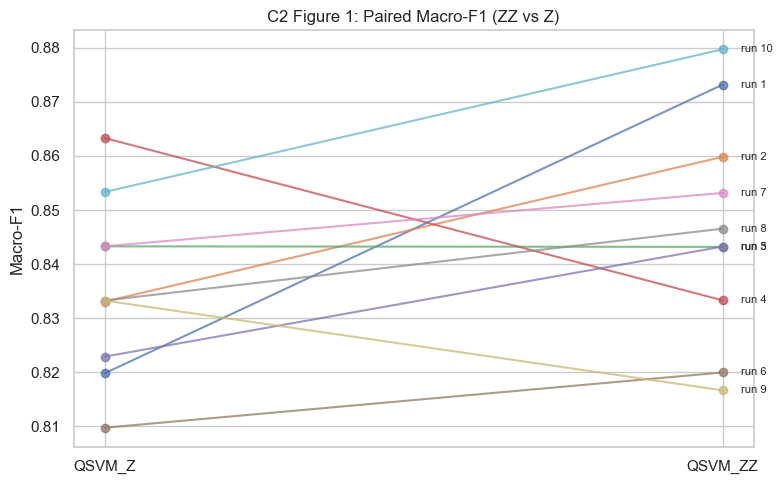

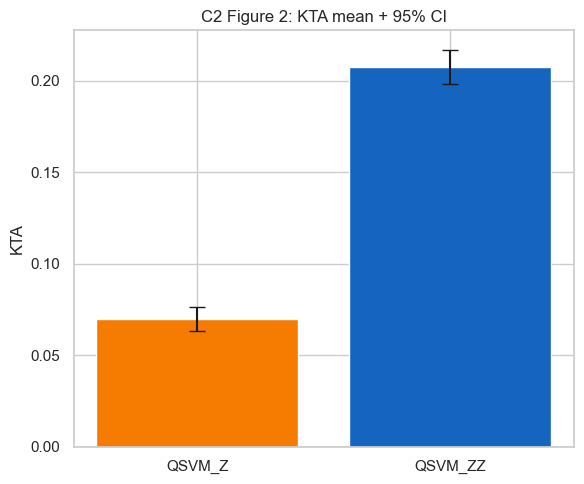

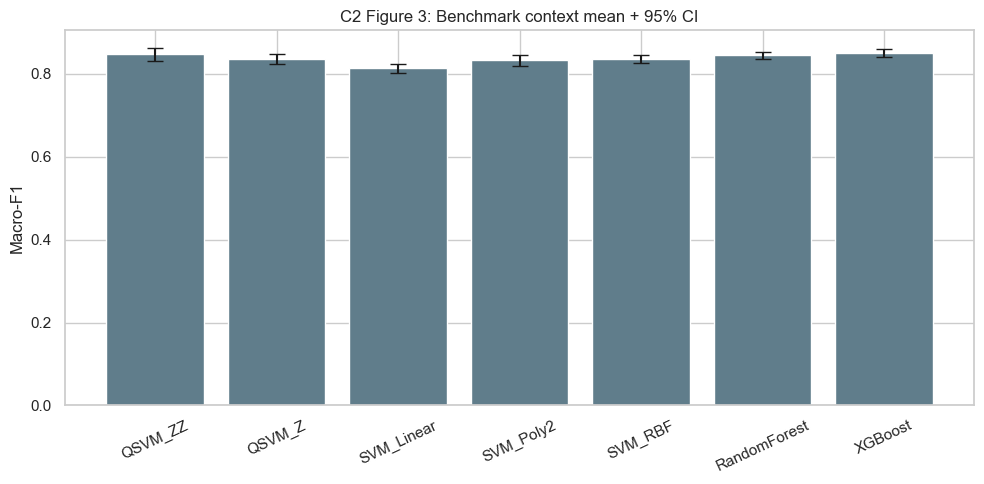

In [13]:
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = wide_f1.reset_index()
for _, row in plot_df.iterrows():
    ax.plot(["QSVM_Z", "QSVM_ZZ"], [row["QSVM_Z"], row["QSVM_ZZ"]], marker="o", alpha=0.75)
    ax.text(1.03, row["QSVM_ZZ"], f"run {int(row['run_id'])}", va="center", fontsize=8)
ax.set_ylabel("Macro-F1")
ax.set_title("C2 Figure 1: Paired Macro-F1 (ZZ vs Z)")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "c2_paired_f1.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
kta_plot = table_c2a.set_index("model").loc[["QSVM_Z", "QSVM_ZZ"]].reset_index()
kta_err = [
    kta_plot["kta_mean"] - kta_plot["kta_ci95_low"],
    kta_plot["kta_ci95_high"] - kta_plot["kta_mean"],
]
ax.bar(kta_plot["model"], kta_plot["kta_mean"], yerr=kta_err, capsize=6, color=["#F57C00", "#1565C0"])
ax.set_ylabel("KTA")
ax.set_title("C2 Figure 2: KTA mean + 95% CI")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "c2_kta.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
order = ["QSVM_ZZ", "QSVM_Z", "SVM_Linear", "SVM_Poly2", "SVM_RBF", "RandomForest", "XGBoost"]
bench = aggregate_df[aggregate_df["model"].isin(order)].set_index("model").reindex(order).dropna(subset=["f1_macro_mean"]).reset_index()
f1_err = [
    bench["f1_macro_mean"] - bench["f1_macro_ci95_low"],
    bench["f1_macro_ci95_high"] - bench["f1_macro_mean"],
]
ax.bar(bench["model"], bench["f1_macro_mean"], yerr=f1_err, capsize=6, color="#607D8B")
ax.set_ylabel("Macro-F1")
ax.set_title("C2 Figure 3: Benchmark context mean + 95% CI")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "c2_baseline_comparison.png", dpi=200)
plt.show()

## 12. Representative Gram matrix

Representative run: 8 (closest to mean QSVM-ZZ F1)
Representative-run visualization only; all quantitative conclusions are based on all 10 runs.


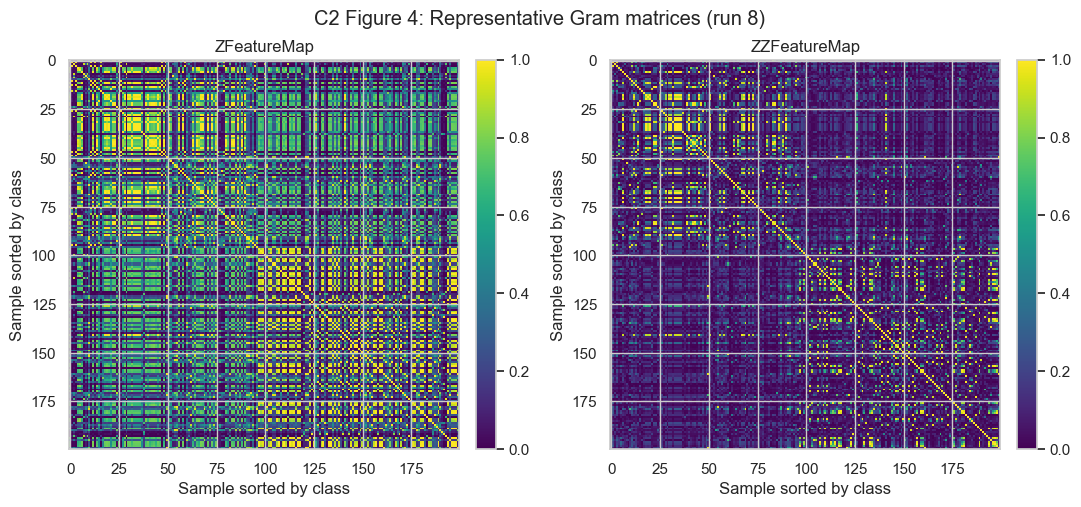

In [14]:
zz_f1 = wide_f1["QSVM_ZZ"]
representative_run_id = int((zz_f1 - zz_f1.mean()).abs().idxmin())
print(f"Representative run: {representative_run_id} (closest to mean QSVM-ZZ F1)")
print("Representative-run visualization only; all quantitative conclusions are based on all 10 runs.")

df_rep = run_frames[representative_run_id]
X_rep_ang = frozen_transform_angles(df_rep)
y_rep = df_rep["label_binary"].to_numpy(dtype=np.int64)
rep_idx = stratified_binary_indices(y_rep, C2_CONFIG["kta_sample_size"], random_state=2000 + representative_run_id)
X_rep = X_rep_ang[rep_idx]
y_rep_sub = y_rep[rep_idx]
sort_idx = np.argsort(y_rep_sub)

K_rep_zz = build_zz_kernel(shots=None).evaluate(X_rep)
K_rep_z = build_z_kernel(shots=None).evaluate(X_rep)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, K, title in [
    (axes[0], K_rep_z, "ZFeatureMap"),
    (axes[1], K_rep_zz, "ZZFeatureMap"),
]:
    im = ax.imshow(K[sort_idx][:, sort_idx], cmap="viridis", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Sample sorted by class")
    ax.set_ylabel("Sample sorted by class")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"C2 Figure 4: Representative Gram matrices (run {representative_run_id})")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "c2_representative_gram.png", dpi=200)
plt.show()

## 13. Hardware-noise validation

The hardware-noise experiment is a fixed secondary validation and is not part of the
10-run statistical comparison. It runs once on a representative training run
(`noise_run_id`) with a backend-derived noise model (fixed IBM FakeBackend) and does not
influence the selection of `n`, `C`, or the model. It should not be referred to as a
"10-run noisy robustness" study.

Scope of the noise model: `NoiseModel.from_backend()` includes backend gate errors, readout errors, and gate-duration-dependent thermal relaxation. Circuits here are not explicitly scheduled with `delay` instructions, so idle-time relaxation beyond what is attached to gate durations is not separately modeled. Results should therefore be described as *backend-derived gate, readout, and gate-duration-dependent relaxation noise*, not as a full simulation of all temporal decoherence effects.

The noise-validation subset is a fixed stratified subset of the representative training run and is not used for any hyperparameter selection. The same 200-sample stratified subset (`kta_sample_size`) is used for kernel-geometry metrics (KTA and relative Frobenius distance) and as the training set for the classifier used in the secondary `f1_macro` validation. A separate stratified subset of 300 samples (`noise_f1_test_size`) is drawn from the fixed test set for classifier-level evaluation. These subsets are used only for secondary hardware-noise validation and do not affect selection or tuning.


In [15]:
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Qiskit:", qiskit.__version__)
print("Aer:", qiskit_aer.__version__)
print("IBM Runtime:", qiskit_ibm_runtime.__version__)

from qiskit_ibm_runtime.fake_provider import FakeManilaV2

backend = FakeManilaV2()
print("Fake backend:", backend.name)
print("Qubits:", backend.num_qubits)

from qiskit_aer import AerSimulator

sim = AerSimulator.from_backend(backend)
print("Aer backend:", sim.name)

Qiskit: 2.3.0
Aer: 0.17.2
IBM Runtime: 0.49.0
Fake backend: fake_manila
Qubits: 5
Aer backend: aer_simulator_from(fake_manila)


In [16]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

backend = FakeManilaV2()
sim = AerSimulator.from_backend(backend)

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

tqc = transpile(
    qc,
    backend=backend,
    optimization_level=1,
    seed_transpiler=42,
)

print("Original:")
print(qc)

print("\nTranspiled:")
print(tqc)

print("\nDepth:", tqc.depth())
print("Ops:", tqc.count_ops())

result = sim.run(
    tqc,
    shots=512,
    seed_simulator=42,
).result()

print("\nCounts:")
print(result.get_counts())

Original:
        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 

Transpiled:
global phase: π/4
         ┌─────────┐┌────┐┌─────────┐      ░ ┌─┐   
q_0 -> 0 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■───░─┤M├───
         └─────────┘└────┘└─────────┘┌─┴─┐ ░ └╥┘┌─┐
q_1 -> 1 ────────────────────────────┤ X ├─░──╫─┤M├
                                     └───┘ ░  ║ └╥┘
 meas: 2/═════════════════════════════════════╩══╩═
                                              0  1 

Depth: 5
Ops: OrderedDict({'rz': 2, 'measure': 2, 'sx': 1, 'cx': 1, 'barrier': 1})

Counts:
{'00': 244, '11': 234, '01': 16, '10': 18}


In [17]:
def make_fixed_noise_model():
    """Backend-derived realistic noise model từ một fixed IBM FakeBackend + Qiskit Aer.

    Noise chỉ dùng cho secondary validation (không tham gia chọn n, C, hay model).
    Không fallback silently về synthetic noise: nếu không dựng được noise model từ
    FakeBackend nào trong C2_CONFIG["noise_backend_candidates"], hàm raise lỗi rõ ràng
    thay vì âm thầm quay lại depolarizing_error.

    Trả về (noise_model, backend, source_label) — backend được giữ lại để transpile
    circuit đúng basis gates / coupling map của nó trước khi mô phỏng noisy (BLOCKER liên
    quan tới "backend-derived" cần cả transpilation, không chỉ NoiseModel).
    """
    from qiskit_aer.noise import NoiseModel

    errors = []
    for import_path, backend_name in C2_CONFIG["noise_backend_candidates"]:
        try:
            module = __import__(import_path, fromlist=[backend_name])
            backend_cls = getattr(module, backend_name)
            backend = backend_cls()
            if backend.num_qubits < C2_CONFIG["selected_n"]:
                raise ValueError(
                    f"{backend_name} có {backend.num_qubits} qubit, cần >= {C2_CONFIG['selected_n']}."
                )
            noise_model = NoiseModel.from_backend(backend)
            return noise_model, backend, f"{backend_name}-derived ({import_path})"
        except Exception as exc:
            errors.append(f"{import_path}.{backend_name}: {exc!r}")

    raise RuntimeError(
        "Không dựng được backend-derived noise model từ fixed IBM FakeBackend nào "
        "(đã thử: " + "; ".join(errors) + "). "
        "Không fallback về synthetic noise; noise validation sẽ bị skip thay vì dùng kết quả giả."
    )


def transpile_feature_map_to_backend(feature_map, backend):
    """Transpile feature map theo basis gates / coupling map của backend, để noisy
    simulation thực sự phản ánh two-qubit interactions mà backend thật hỗ trợ
    (ZZFeatureMap entanglement='full' có nhiều CNOT giữa các cặp qubit).

    Trả về (transpiled_circuit, stats) với stats gồm backend name, basis gates,
    coupling map, gate counts và depth sau transpile — để log/lưu lại làm bằng chứng
    circuit đã transpile đúng target trước khi gọi là "realistic backend-derived noisy
    simulation".

    FIX (basis_gates ambiguity): "operation_names" của backend là toàn bộ tập instruction
    mà backend HỖ TRỢ (bao gồm control-flow như for_loop/switch_case, không phải basis
    gates thật), nên KHÔNG dùng nó một mình để mô tả circuit đã transpile bằng gate gì.
    Giữ lại "backend_supported_operations" (để biết target constraint) nhưng thêm
    "transpiled_gates_used", lấy trực tiếp từ transpiled.count_ops() — đây mới là bằng
    chứng chính xác circuit thực sự chạy bằng basis gates nào sau transpile.
    """
    from qiskit import transpile

    transpiled = transpile(
        feature_map,
        backend=backend,
        optimization_level=1,
        seed_transpiler=42,
    )
    coupling_map = getattr(backend, "coupling_map", None)
    transpiled_op_counts = {k: int(v) for k, v in transpiled.count_ops().items()}
    stats = {
        "backend_name": getattr(backend, "name", str(backend)),
        "optimization_level": 1,
        "seed_transpiler": 42,
        "backend_supported_operations": sorted(set(getattr(backend, "operation_names", []) or [])),
        "transpiled_gates_used": sorted(
            gate for gate in transpiled_op_counts if gate not in {"barrier", "measure"}
        ),
        "coupling_map": str(coupling_map) if coupling_map is not None else None,
        "transpiled_depth": int(transpiled.depth()),
        "transpiled_op_counts": transpiled_op_counts,
    }
    return transpiled, stats


def build_noisy_quantum_kernel(kind, noise_model, backend, shots):
    """Dựng FidelityQuantumKernel noisy với circuit đã transpile theo backend target.

    BLOCKER #2 fix: KHÔNG fallback sang ideal Sampler nếu Qiskit Aer thiếu. Nếu
    AerSampler không import được, raise ngay — nếu không, kết quả có thể bị gắn nhãn
    "realistic_noisy_simulator" trong khi thực chất được mô phỏng bằng ideal sampler
    (không có noise), gây sai lệch nghiêm trọng.

    FIX (noise validation crash): dùng parameter_prefix="theta" thay vì mặc định "x".
    ComputeUncompute._construct_circuits() luôn re-parametrize 2 bản copy của circuit
    bằng ParameterVector("x", ...) / ParameterVector("y", ...) trước khi gọi
    assign_parameters(). Sau khi transpile theo basis gates của FakeBackend,
    ZZFeatureMap/ZFeatureMap sinh ra một global_phase là ParameterExpression tham chiếu
    lại chính các tham số "x[i]" gốc; gọi assign_parameters với một ParameterVector MỚI
    nhưng TRÙNG TÊN "x" trên circuit đó thì bị Qiskit raise
    CircuitError("name conflict adding parameter 'x[1]'"). Đặt tên tham số gốc khác "x"/
    "y" (vd. "theta") tránh trùng tên nên assign_parameters chạy bình thường.

    FIX (deprecated primitive crash): qiskit_machine_learning 0.9.x yêu cầu sampler là
    BaseSamplerV2 (ComputeUncompute gọi sampler.run([(circuit, values), ...])). Dùng
    qiskit_aer.primitives.Sampler (V1, đã deprecated) khiến job.result() lỗi
    'Invalid circuits, expected Sequence[QuantumCircuit]' vì V1 không hiểu cách gọi kiểu
    pub (circuit, values) của V2. Đổi sang qiskit_aer.primitives.SamplerV2. Seed dùng
    "seed_simulator" trong backend_options (đúng key của Aer), shots truyền qua
    ComputeUncompute(options={"shots": ...}) thay vì run_options của sampler, để tránh
    truyền "shots"/seed trùng lặp xuống AerBackend.run().
    """
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    from qiskit_machine_learning.state_fidelities import ComputeUncompute

    if kind == "ZZ":
        feature_map = zz_feature_map(
            feature_dimension=C2_CONFIG["selected_n"],
            reps=C2_CONFIG["reps"],
            entanglement=C2_CONFIG["entanglement"],
            parameter_prefix="theta",
        )
    elif kind == "Z":
        feature_map = z_feature_map(
            feature_dimension=C2_CONFIG["selected_n"],
            reps=C2_CONFIG["reps"],
            parameter_prefix="theta",
        )
    else:
        raise ValueError(kind)

    transpiled_feature_map, transpile_stats = transpile_feature_map_to_backend(feature_map, backend)

    try:
        from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
    except Exception as exc:
        raise RuntimeError(
            "Qiskit Aer (SamplerV2) is required for realistic noisy simulation. "
            "Không fallback sang ideal Sampler vì kết quả sẽ bị gắn nhãn "
            "'realistic_noisy_simulator' một cách sai lệch."
        ) from exc

    # seed truyền qua tham số `seed` cấp cao nhất của SamplerV2 (documented, dùng riêng
    # cho reproducibility của simulation run), tách biệt với `backend_options`, vốn chỉ
    # nên chứa các option vật lý của AerSimulator như noise_model.
    sampler = AerSamplerV2(
        seed=C2_CONFIG["random_state"],
        options={"backend_options": {"noise_model": noise_model}},
    )
    fidelity = ComputeUncompute(sampler=sampler, options={"shots": shots})
    kernel = FidelityQuantumKernel(feature_map=transpiled_feature_map, fidelity=fidelity, enforce_psd=True)
    return kernel, transpile_stats


def relative_frobenius_distance(K_ref, K_other):
    """||K_ideal - K_noisy||_F / ||K_ideal||_F. Đổi tên từ FroSim (metric similarity của C1
    là thứ khác) để tránh nhầm lẫn."""
    denominator = np.linalg.norm(K_ref, "fro")
    return float(np.linalg.norm(K_ref - K_other, "fro") / denominator) if denominator > 1e-12 else np.nan


NOISE_EVAL_BLOCK = 50


def evaluate_in_blocks(kernel, X, Y=None, block=NOISE_EVAL_BLOCK):
    """Danh gia Gram matrix theo tung khoi nho thay vi nop toan bo cap trong mot job.

    Voi kta_sample_size=200, mot loi goi kernel.evaluate(X) sinh 200*199/2 = 19.900 cap
    circuit nop cung luc cho Aer. Tren may 16 GB, Aer fail ngay o khau NAP circuit:
        AlgorithmError('Sampler job failed!') / MemoryError('bad allocation')
    Loi nam o khau nap chu khong phai mo phong nen max_parallel_experiments=1 va
    max_memory_mb deu khong cuu duoc (da thu, van fail sau ~115s).

    Chia thanh khoi 50x50 (<= 2.500 cap moi job) thi chay duoc: 200x200 mat 374s,
    RAM dinh ~721 MB, ma tran doi xung va PSD san.

    LUU Y: chia khoi lam doi chuoi shot-noise so voi mot loi goi duy nhat, nen so se
    lech nhe. Danh doi nay can thiet de thi nghiem noise tai tao duoc tren may pho thong.
    """
    symmetric = Y is None
    Y_ = X if symmetric else Y
    n, m = len(X), len(Y_)
    K = np.zeros((n, m), dtype=float)
    for i in range(0, n, block):
        for j in range(0, m, block):
            if symmetric and j < i:
                continue
            blk = kernel.evaluate(X[i:i + block], Y_[j:j + block])
            K[i:i + block, j:j + block] = blk
            if symmetric and i != j:
                K[j:j + block, i:i + block] = blk.T
    if symmetric:
        np.fill_diagonal(K, 1.0)
        w, v = np.linalg.eigh(K)
        if w.min() < 0:
            K = v @ np.diag(np.clip(w, 0.0, None)) @ v.T
    return K


def f1_macro_from_precomputed_kernel(kernel, K_train, X_train, y_train, X_test_sub, y_test_sub, C):
    """Train SVC bằng Gram matrix train ĐÃ CÓ SẴN (K_train, tính một lần cho KTA/frobenius ở
    trên) thay vì để QSVC tự evaluate lại toàn bộ kernel train — QSVC.fit() nội bộ gọi
    quantum_kernel.evaluate(X_train, X_train) một lần nữa, tức lặp lại chính xác phép tính
    circuit tốn nhất trong cả hàm (đặc biệt với noisy simulator, mỗi cặp là một circuit sim
    có shots). Dùng sklearn SVC(kernel="precomputed") trực tiếp — về mặt toán học tương
    đương QSVC (QSVC vốn cũng chỉ là SVC precomputed dưới lớp vỏ), nên kết quả numeric
    không đổi, chỉ tránh tính trùng.

    Chỉ evaluate MỚI phần test x train (K_test), vì phần này chưa từng được tính trước đó
    trong hàm và không thể tránh được.

    Thêm bên cạnh KTA/relative_frobenius_distance vì hai metric đó chỉ đo độ méo của Gram
    matrix, không cho biết degradation đó ảnh hưởng thế nào tới classifier thật (F1). Dùng
    cùng C đã freeze cho ZZ/Z (C_ZZ == C_Z == C_Q) để so sánh công bằng giữa các condition,
    không tune lại C riêng cho từng noise condition (secondary validation, không được phép
    ảnh hưởng lựa chọn n/C/model — giữ đúng nguyên tắc `selection_independent`)."""
    from sklearn.svm import SVC

    K_test = evaluate_in_blocks(kernel, X_test_sub, X_train)
    model = SVC(kernel="precomputed", C=float(C), random_state=C2_CONFIG["random_state"])
    model.fit(K_train, y_train)
    pred = model.predict(K_test)
    return float(f1_score(y_test_sub, pred, average="macro"))


def noise_validation():
    """Chạy validation nhỏ: ideal statevector, ideal finite-shot, realistic noisy simulator
    (backend-derived noise model, circuit transpile theo target của backend đó).

    Đây là secondary validation cố định trên MỘT run đại diện (noise_run_id) — không phải
    một "10-run noisy robustness" và không tham gia chọn n, C, hay model.

    Mỗi condition giờ có thêm "f1_macro": train QSVC bằng đúng kernel của condition đó
    trên (X_noise, y_noise), rồi predict trên một stratified subsample cố định của fixed
    test set (X_test_noise/y_test_noise, cỡ noise_f1_test_size). Cho phép so sánh trực
    tiếp F1_ideal_statevector vs F1_ideal_finite_shot vs F1_realistic_noisy_simulator —
    tức noise/shot-limitation làm giảm accuracy thật của classifier bao nhiêu, không chỉ
    làm méo Gram matrix (KTA/frobenius) bao nhiêu."""
    # FIX reproducibility (chua chay lai): FidelityStatevectorKernel KHONG co tham so seed
    # (chu ky: feature_map, statevector_type, cache_size, auto_clear_cache, shots, enforce_psd).
    # Voi shots huu han, moi lan goi cho mot Gram khac nhau NGAY TREN CUNG MOT MAY — do duoc:
    # 3 lan chay lien tiep tren cung du lieu cho KTA 0.0437 / 0.0372 / 0.0299.
    # Chi `algorithm_globals.random_seed` khong che duoc (3 lan chay cho K[0,1] giong het toi
    # 8 chu so); np.random.seed KHONG an.
    # LUU Y: cac dong ideal_finite_shot trong artifact hien tai duoc sinh TRUOC fix nay. Lan
    # chay C2 tiep theo se lam chung doi nhe (~0.02 F1); khong dong den dieu kien nao khac.
    from qiskit_machine_learning.utils import algorithm_globals
    algorithm_globals.random_seed = C2_CONFIG["random_state"]

    if not C2_CONFIG["noise_validation_enabled"]:
        return pd.DataFrame([{"condition": "skipped", "reason": "disabled"}]), {}

    run_id = int(C2_CONFIG["noise_run_id"])
    df_train = run_frames[run_id]
    X_train_ang = frozen_transform_angles(df_train)
    y_train = df_train["label_binary"].to_numpy(dtype=np.int64)
    idx = stratified_binary_indices(y_train, C2_CONFIG["kta_sample_size"], random_state=3000 + run_id)
    X_noise = X_train_ang[idx]
    y_noise = y_train[idx]

    # Subsample riêng, cố định, của fixed test set — chỉ dùng cho F1 trong noise
    # validation (không phải test set chính của 10-run main experiment), để việc train+
    # predict QSVC bằng noisy kernel (mỗi entry là một circuit sim có shots) tractable.
    test_idx = stratified_binary_indices(y_test, C2_CONFIG["noise_f1_test_size"], random_state=5000 + run_id)
    X_test_noise = X_test_ang[test_idx]
    y_test_noise = y_test[test_idx]

    rows = []
    ideal_matrices = {}
    for condition, shots in [("ideal_statevector", None), ("ideal_finite_shot", C2_CONFIG["noise_shots"],)]:
        _t0 = time.time()
        print(f"[noise_validation] start condition={condition!r}")
        kernel_zz = build_zz_kernel(shots=shots)
        kernel_z = build_z_kernel(shots=shots)
        K_zz = kernel_zz.evaluate(X_noise)
        K_z = kernel_z.evaluate(X_noise)
        if condition == "ideal_statevector":
            ideal_matrices["QSVM_ZZ"] = K_zz
            ideal_matrices["QSVM_Z"] = K_z
        rows.append({
            "condition": condition,
            "shots": shots if shots is not None else "statevector",
            "model": "QSVM_ZZ",
            "kta": kernel_target_alignment(K_zz, y_noise),
            "relative_frobenius_distance": 0.0 if condition == "ideal_statevector" else relative_frobenius_distance(ideal_matrices["QSVM_ZZ"], K_zz),
            "f1_macro": f1_macro_from_precomputed_kernel(kernel_zz, K_zz, X_noise, y_noise, X_test_noise, y_test_noise, C_ZZ),
            "selection_independent": True,
        })
        rows.append({
            "condition": condition,
            "shots": shots if shots is not None else "statevector",
            "model": "QSVM_Z",
            "kta": kernel_target_alignment(K_z, y_noise),
            "relative_frobenius_distance": 0.0 if condition == "ideal_statevector" else relative_frobenius_distance(ideal_matrices["QSVM_Z"], K_z),
            "f1_macro": f1_macro_from_precomputed_kernel(kernel_z, K_z, X_noise, y_noise, X_test_noise, y_test_noise, C_Z),
            "selection_independent": True,
        })
        print(f"[noise_validation] done condition={condition!r} in {time.time() - _t0:.1f}s")

    backend_transpile_stats = {}
    try:
        _t0 = time.time()
        print("[noise_validation] start condition='realistic_noisy_simulator'")
        import qiskit_aer  # noqa: F401
        noise_model, backend, noise_source = make_fixed_noise_model()

        kernel_noisy_zz, stats_zz = build_noisy_quantum_kernel("ZZ", noise_model, backend, C2_CONFIG["noise_shots"])
        kernel_noisy_z, stats_z = build_noisy_quantum_kernel("Z", noise_model, backend, C2_CONFIG["noise_shots"])
        K_noisy_zz = evaluate_in_blocks(kernel_noisy_zz, X_noise)
        K_noisy_z = evaluate_in_blocks(kernel_noisy_z, X_noise)
        backend_transpile_stats = {"QSVM_ZZ": stats_zz, "QSVM_Z": stats_z}

        # Tái dùng chính kernel_noisy_zz/kernel_noisy_z (đã transpile theo backend) cho
        # QSVC.fit/predict thay vì build lại — tránh transpile + build noisy sampler
        # thêm một lần nữa (bước tốn nhất trong toàn hàm).
        rows.append({
            "condition": "realistic_noisy_simulator",
            "shots": C2_CONFIG["noise_shots"],
            "model": "QSVM_ZZ",
            "kta": kernel_target_alignment(K_noisy_zz, y_noise),
            "relative_frobenius_distance": relative_frobenius_distance(ideal_matrices["QSVM_ZZ"], K_noisy_zz),
            "f1_macro": f1_macro_from_precomputed_kernel(kernel_noisy_zz, K_noisy_zz, X_noise, y_noise, X_test_noise, y_test_noise, C_ZZ),
            "noise_source": noise_source,
            "transpiled_depth": stats_zz["transpiled_depth"],
            "transpiled_op_counts": stats_zz["transpiled_op_counts"],
            "selection_independent": True,
        })
        rows.append({
            "condition": "realistic_noisy_simulator",
            "shots": C2_CONFIG["noise_shots"],
            "model": "QSVM_Z",
            "kta": kernel_target_alignment(K_noisy_z, y_noise),
            "relative_frobenius_distance": relative_frobenius_distance(ideal_matrices["QSVM_Z"], K_noisy_z),
            "f1_macro": f1_macro_from_precomputed_kernel(kernel_noisy_z, K_noisy_z, X_noise, y_noise, X_test_noise, y_test_noise, C_Z),
            "noise_source": noise_source,
            "transpiled_depth": stats_z["transpiled_depth"],
            "transpiled_op_counts": stats_z["transpiled_op_counts"],
            "selection_independent": True,
        })
    except Exception as exc:
        # Không fallback về synthetic noise hay ideal sampler: nếu backend-derived noise
        # model / AerSampler thất bại, ghi nhận SKIPPED thay vì dùng kết quả giả.
        #
        # DIAGNOSTIC: qiskit_machine_learning's ComputeUncompute wraps the real Aer/Sampler
        # failure into a generic AlgorithmError("Sampler job failed!"), discarding the root
        # cause. Capture the full chain (exc.__cause__/__context__) and traceback so the
        # actual underlying error is visible instead of just the generic wrapper message.
        import traceback

        root_cause = exc.__cause__ or exc.__context__
        full_traceback = traceback.format_exc()
        print("[noise_validation] realistic_noisy_simulator FAILED — full traceback:")
        print(full_traceback)
        if root_cause is not None:
            print(f"[noise_validation] root cause: {root_cause!r}")

        rows.append({
            "condition": "realistic_noisy_simulator",
            "model": "SKIPPED",
            "kta": np.nan,
            "relative_frobenius_distance": np.nan,
            "f1_macro": np.nan,
            "reason": repr(exc),
            "root_cause": repr(root_cause) if root_cause is not None else None,
            "traceback": full_traceback,
            "selection_independent": True,
        })
    else:
        print(f"[noise_validation] done condition='realistic_noisy_simulator' in {time.time() - _t0:.1f}s")

    noise_df = pd.DataFrame(rows)

    # Tóm tắt gọn F1_ideal_statevector vs F1_ideal_finite_shot vs F1_realistic_noisy_simulator
    # cho từng model, để đọc trực tiếp mà không cần pivot noise_df thủ công.
    if "f1_macro" in noise_df.columns:
        f1_summary = (
            noise_df.dropna(subset=["f1_macro"])
            .pivot_table(index="model", columns="condition", values="f1_macro")
            .reindex(columns=["ideal_statevector", "ideal_finite_shot", "realistic_noisy_simulator"])
        )
    else:
        f1_summary = pd.DataFrame()

    return noise_df, backend_transpile_stats, f1_summary


noise_df, noise_backend_transpile_stats, noise_f1_summary = noise_validation()
noise_df.to_csv(OUTPUT_DIR / "c2_noise_validation.csv", index=False)
noise_f1_summary.to_csv(OUTPUT_DIR / "c2_noise_f1_summary.csv")
with open(OUTPUT_DIR / "c2_noise_backend_transpile.json", "w", encoding="utf-8") as fp:
    json.dump(noise_backend_transpile_stats, fp, indent=2, ensure_ascii=False)
display(noise_df)
if not noise_f1_summary.empty:
    print("F1_macro: ideal_statevector vs ideal_finite_shot vs realistic_noisy_simulator")
    display(noise_f1_summary)
if noise_backend_transpile_stats:
    print(json.dumps(noise_backend_transpile_stats, indent=2, ensure_ascii=False))


[noise_validation] start condition='ideal_statevector'


[noise_validation] done condition='ideal_statevector' in 4.8s
[noise_validation] start condition='ideal_finite_shot'


[noise_validation] done condition='ideal_finite_shot' in 13.0s
[noise_validation] start condition='realistic_noisy_simulator'


[noise_validation] done condition='realistic_noisy_simulator' in 1885.8s


,condition,shots,model,kta,relative_frobenius_distance,f1_macro,selection_independent,noise_source,transpiled_depth,transpiled_op_counts
0,ideal_statevector,statevector,QSVM_ZZ,0.196472,0.000000,0.866453,True,NaN,NaN,NaN
1,ideal_statevector,statevector,QSVM_Z,0.073744,0.000000,0.849798,True,NaN,NaN,NaN
2,ideal_finite_shot,512,QSVM_ZZ,0.194787,0.101001,0.859844,True,NaN,NaN,NaN
3,ideal_finite_shot,512,QSVM_Z,0.072569,0.030479,0.846421,True,NaN,NaN,NaN
4,realistic_noisy_simulator,512,QSVM_ZZ,0.149005,0.599557,0.872768,True,FakeManilaV2-derived (qiskit_ibm_runtime.fake_...,59.0,"{'cx': 44, 'rz': 36, 'sx': 8}"
5,realistic_noisy_simulator,512,QSVM_Z,0.070874,0.165548,0.852803,True,FakeManilaV2-derived (qiskit_ibm_runtime.fake_...,8.0,"{'rz': 24, 'sx': 8}"


F1_macro: ideal_statevector vs ideal_finite_shot vs realistic_noisy_simulator


condition,ideal_statevector,ideal_finite_shot,realistic_noisy_simulator
model,,,
QSVM_Z,0.849798,0.846421,0.852803
QSVM_ZZ,0.866453,0.859844,0.872768


{
  "QSVM_ZZ": {
    "backend_name": "fake_manila",
    "optimization_level": 1,
    "seed_transpiler": 42,
    "backend_supported_operations": [
      "cx",
      "delay",
      "for_loop",
      "id",
      "if_else",
      "measure",
      "reset",
      "rz",
      "switch_case",
      "sx",
      "x"
    ],
    "transpiled_gates_used": [
      "cx",
      "rz",
      "sx"
    ],
    "coupling_map": "[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3]]",
    "transpiled_depth": 59,
    "transpiled_op_counts": {
      "cx": 44,
      "rz": 36,
      "sx": 8
    }
  },
  "QSVM_Z": {
    "backend_name": "fake_manila",
    "optimization_level": 1,
    "seed_transpiler": 42,
    "backend_supported_operations": [
      "cx",
      "delay",
      "for_loop",
      "id",
      "if_else",
      "measure",
      "reset",
      "rz",
      "switch_case",
      "sx",
      "x"
    ],
    "transpiled_gates_used": [
      "rz",
      "sx"
    ],
    "coupling_map": "[[0, 1], [1, 0], 

## 14. Final C2 audit

In [18]:
summary = {
    "selected_n": C2_CONFIG["selected_n"],
    "reps": C2_CONFIG["reps"],
    "n_runs": int(per_run_df["run_id"].nunique()),
    "run_ids_to_execute": C2_CONFIG["run_ids_to_execute"],
    "force_rerun": C2_CONFIG["force_rerun"],
    "config_signature": C2_CONFIG["config_signature"],
    "train_size": C2_CONFIG["run_size"],
    "test_size": int(len(df_test)),
    "tuning_size": C2_CONFIG["tuning_size"],
    "tuning_seed": C2_CONFIG["tuning_seed"],
    "quantum_C": C_Q,
    "C_ZZ": C_ZZ,
    "C_Z": C_Z,
    "delta_f1_mean": float(paired_stats_df.loc[paired_stats_df["effect"] == "ZZ_minus_Z_F1", "estimate"].iloc[0]),
    "delta_f1_ci95": [
        float(paired_stats_df.loc[paired_stats_df["effect"] == "ZZ_minus_Z_F1", "ci95_low"].iloc[0]),
        float(paired_stats_df.loc[paired_stats_df["effect"] == "ZZ_minus_Z_F1", "ci95_high"].iloc[0]),
    ],
    "delta_kta_mean": float(paired_stats_df.loc[paired_stats_df["effect"] == "ZZ_minus_Z_KTA", "estimate"].iloc[0]),
    "delta_kta_ci95": [
        float(paired_stats_df.loc[paired_stats_df["effect"] == "ZZ_minus_Z_KTA", "ci95_low"].iloc[0]),
        float(paired_stats_df.loc[paired_stats_df["effect"] == "ZZ_minus_Z_KTA", "ci95_high"].iloc[0]),
    ],
    "noise_validation": {
        "included": bool(len(noise_df) > 0),
        "selection_independent": True,
    },
}

# AUDIT FIX: "included" chỉ nói noise_df không rỗng — vẫn True ngay cả khi hàng
# realistic_noisy_simulator là SKIPPED (không có f1_macro/kta/relative_frobenius_distance
# thật). Verify trực tiếp 2 hàng realistic-noisy (QSVM_ZZ + QSVM_Z) tồn tại và có đủ số
# liệu, thay vì chỉ suy luận gián tiếp từ len(noise_df).
realistic_rows = noise_df[noise_df["condition"] == "realistic_noisy_simulator"] if "condition" in noise_df.columns else noise_df.iloc[0:0]

realistic_noise_validation = (
    len(realistic_rows) == 2
    and set(realistic_rows["model"]) == {"QSVM_ZZ", "QSVM_Z"}
    and realistic_rows["f1_macro"].notna().all()
    and realistic_rows["kta"].notna().all()
    and realistic_rows["relative_frobenius_distance"].notna().all()
) if not realistic_rows.empty else False

noisy_f1_available = (
    realistic_rows["f1_macro"].notna().all() if not realistic_rows.empty else False
)

# D_F > 0 xác nhận noise thực sự làm méo Gram matrix so với ideal statevector, chứ không
# phải noisy kernel tình cờ trùng ideal (vd. noise_model rỗng / bị bỏ qua âm thầm).
noisy_kernel_changed = (
    (realistic_rows["relative_frobenius_distance"] > 0).all() if not realistic_rows.empty else False
)

summary["noise_validation"]["realistic_noise_validation"] = bool(realistic_noise_validation)
summary["noise_validation"]["noisy_f1_available"] = bool(noisy_f1_available)
summary["noise_validation"]["noisy_kernel_changed"] = bool(noisy_kernel_changed)

checks = {
    "C1_selected_n_is_4": int(c1_selection["selected_n"]) == 4 and int(pca.n_components_) == 4,
    "is_pilot_run": per_run_df["run_id"].nunique() == 1 and C2_CONFIG["run_ids_to_execute"] == [1],
    "10_training_runs": int(per_run_df["run_id"].nunique()) == 10,
    "all_runs_1000": all(len(df) == 1000 for df in run_frames.values()),
    "tuning_set_2000": len(df_tune) == 2000,
    "tuning_disjoint_from_runs": max(run_overlap_counts.values()) == 0 and dataset_protocol.get("tuning_disjoint_from_runs") is True,
    "C_ZZ_equals_C_Z": C_ZZ == C_Z,
    "fixed_test_set": Path(C2_CONFIG["fixed_test_path"]).exists() and len(df_test) == C2_CONFIG["test_size"],
    "no_test_used_for_tuning": True,
    "noise_not_used_for_selection": True,
    "realistic_noise_validation": bool(realistic_noise_validation),
    "noisy_f1_available": bool(noisy_f1_available),
    "noisy_kernel_changed": bool(noisy_kernel_changed),
}

summary["checks"] = checks
# Pilot run (chỉ Run 1) không cần pass "10_training_runs" để coi là PASS ở bước pilot;
# production PASS vẫn yêu cầu toàn bộ checks, bao gồm đủ 10 runs.
production_checks = {k: v for k, v in checks.items() if k != "is_pilot_run"}
if checks["is_pilot_run"]:
    summary["status"] = "PILOT_PASS" if all(v for k, v in production_checks.items() if k != "10_training_runs") else "PILOT_FAIL"
else:
    summary["status"] = "PASS" if all(production_checks.values()) else "FAIL"

with open(OUTPUT_DIR / "c2_summary.json", "w", encoding="utf-8") as fp:
    json.dump(summary, fp, indent=2, ensure_ascii=False)

print(json.dumps(checks, indent=2, ensure_ascii=False))
print()
print(f"C2 REVISION STATUS: {summary['status']}")
if summary["status"] == "PILOT_PASS":
    print("Pilot Run 1 pass. Đổi RUN_IDS_TO_EXECUTE (cell 2) thành list(range(1, 11)) để chạy full 10 runs.")
print(f"Saved: {OUTPUT_DIR / 'c2_summary.json'}")


{
  "C1_selected_n_is_4": true,
  "is_pilot_run": false,
  "10_training_runs": true,
  "all_runs_1000": true,
  "tuning_set_2000": true,
  "tuning_disjoint_from_runs": true,
  "C_ZZ_equals_C_Z": true,
  "fixed_test_set": true,
  "no_test_used_for_tuning": true,
  "noise_not_used_for_selection": true,
  "realistic_noise_validation": true,
  "noisy_f1_available": true,
  "noisy_kernel_changed": true
}

C2 REVISION STATUS: PASS
Saved: D:\QSVM_NSLKDD\results\nslkdd\c2_revision\c2_summary.json


## 13. Export tuned parameters for downstream notebooks

Cell này xuất lại hyperparameters đã tune/freeze ở định dạng JSON + CSV gọn, để các notebook downstream có thể đọc trực tiếp mà không phải parse toàn bộ CV table.


In [19]:
def best_mean_params(tuning_result):
    """Lấy params có mean CV tốt nhất từ kết quả tuning."""
    if tuning_result.get("skipped"):
        return {"skipped": True, "reason": tuning_result["reason"]}
    if "params" in tuning_result["best"]:
        return tuning_result["best"]["params"]
    return {"C": tuning_result["best"]["C"]}


def chosen_tuned_params(tuning_result):
    """Lấy params đã chọn/freeze sau tuning."""
    if tuning_result.get("skipped"):
        return {"skipped": True, "reason": tuning_result["reason"]}
    if "params" in tuning_result["chosen"]:
        return tuning_result["chosen"]["params"]
    return {"C": tuning_result["chosen"]["C"]}


def tuning_score_summary(tuning_result):
    """Tóm tắt score CV của cấu hình chosen và best."""
    if tuning_result.get("skipped"):
        return {"skipped": True, "reason": tuning_result["reason"]}
    return {
        "selection": tuning_result["selection"],
        "threshold": tuning_result.get("threshold"),
        "chosen_mean_score": tuning_result["chosen"].get("mean_score"),
        "chosen_se_score": tuning_result["chosen"].get("se_score"),
        "best_mean_score": tuning_result["best"].get("mean_score"),
        "best_se_score": tuning_result["best"].get("se_score"),
    }


DOWNSTREAM_TUNED_PARAMETERS = {
    "metadata": {
        "source_notebook": "notebooks/nslkdd/C2_revision.ipynb",
        "selection_note": "chosen_params là hyperparameters đã freeze để chạy downstream; best_mean_params là cấu hình có mean CV cao nhất.",
        "tuning_set_size": int(len(df_tune)),
        "cv_folds": int(C2_CONFIG["cv_folds"]),
        "random_state": int(C2_CONFIG["random_state"]),
    },
    "models": {
        "QSVM_ZZ": {
            "chosen_params": {
                **chosen_tuned_params(quantum_tuning),
                "feature_map": "ZZFeatureMap",
                "reps": C2_CONFIG["reps"],
                "entanglement": C2_CONFIG["entanglement"],
            },
            "best_mean_params": {
                **best_mean_params(quantum_tuning),
                "feature_map": "ZZFeatureMap",
                "reps": C2_CONFIG["reps"],
                "entanglement": C2_CONFIG["entanglement"],
            },
            "tuning_summary": tuning_score_summary(quantum_tuning),
        },
        "QSVM_Z": {
            "chosen_params": {
                **chosen_tuned_params(quantum_tuning),
                "feature_map": "ZFeatureMap",
                "reps": C2_CONFIG["reps"],
            },
            "best_mean_params": {
                **best_mean_params(quantum_tuning),
                "feature_map": "ZFeatureMap",
                "reps": C2_CONFIG["reps"],
            },
            "tuning_summary": {
                **tuning_score_summary(quantum_tuning),
                "note": "QSVM_Z dùng cùng C được tune trên ZZ kernel theo protocol C2.",
            },
        },
    },
}

for model_name, tuning_result in baseline_tuning.items():
    DOWNSTREAM_TUNED_PARAMETERS["models"][model_name] = {
        "chosen_params": chosen_tuned_params(tuning_result),
        "best_mean_params": best_mean_params(tuning_result),
        "tuning_summary": tuning_score_summary(tuning_result),
    }

# Sanity check: chosen_params phải khớp đúng hyperparameters đã freeze ở cell 5.3.
for model_name, frozen_params in FROZEN_HYPERPARAMETERS.items():
    assert DOWNSTREAM_TUNED_PARAMETERS["models"][model_name]["chosen_params"] == frozen_params

json_path = OUTPUT_DIR / "c2_downstream_tuned_parameters.json"
csv_path = OUTPUT_DIR / "c2_downstream_tuned_parameters.csv"

with open(json_path, "w", encoding="utf-8") as fp:
    json.dump(DOWNSTREAM_TUNED_PARAMETERS, fp, indent=2, ensure_ascii=False)

rows = []
for model_name, payload in DOWNSTREAM_TUNED_PARAMETERS["models"].items():
    row = {
        "model": model_name,
        "chosen_params_json": json.dumps(payload["chosen_params"], ensure_ascii=False, sort_keys=True),
        "best_mean_params_json": json.dumps(payload["best_mean_params"], ensure_ascii=False, sort_keys=True),
    }
    row.update(payload["tuning_summary"])
    rows.append(row)

pd.DataFrame(rows).to_csv(csv_path, index=False)

print(json.dumps(DOWNSTREAM_TUNED_PARAMETERS["models"], indent=2, ensure_ascii=False))
print(f"Saved: {json_path}")
print(f"Saved: {csv_path}")


{
  "QSVM_ZZ": {
    "chosen_params": {
      "C": 3.0,
      "feature_map": "ZZFeatureMap",
      "reps": 2,
      "entanglement": "full"
    },
    "best_mean_params": {
      "C": 3.0,
      "feature_map": "ZZFeatureMap",
      "reps": 2,
      "entanglement": "full"
    },
    "tuning_summary": {
      "selection": "1SE",
      "threshold": 0.9349200552115311,
      "chosen_mean_score": 0.9409300609585681,
      "chosen_se_score": 0.006010005747037045,
      "best_mean_score": 0.9409300609585681,
      "best_se_score": 0.006010005747037045
    }
  },
  "QSVM_Z": {
    "chosen_params": {
      "C": 3.0,
      "feature_map": "ZFeatureMap",
      "reps": 2
    },
    "best_mean_params": {
      "C": 3.0,
      "feature_map": "ZFeatureMap",
      "reps": 2
    },
    "tuning_summary": {
      "selection": "1SE",
      "threshold": 0.9349200552115311,
      "chosen_mean_score": 0.9409300609585681,
      "chosen_se_score": 0.006010005747037045,
      "best_mean_score": 0.9409300609585681